## Multi-Filter Edge Detection: A Comparative Study

Mohamed Adnan Palli Konda - M01043513 - CST 4060 - CW 3

In [108]:
# pip install opencv-python numpy scikit-learn dlib mtcnn mediapipe

Edge detection is a crucial technique in image processing, allowing for the identification of boundaries within images. In this project, a variety of classical edge detection filters are applied to a sharpened image, including Sobel, Scharr, Roberts, Prewitt, and Laplacian operators, as well as the Laplacian of Gaussian (LoG) method and Canny edge detection. The goal of this project is to compare the effectiveness of these edge detection techniques in highlighting key features and contours within the image.

We will break down each process into custom substeps, exploring edge detection, segmentation, machine learning classifiers, and advanced applications like face depth estimation. Each section includes custom implementations, code, and explanations of the outputs to deepen our understanding of how these methods work under the hood. Also in this project the image adnanaiimg.jpg used is an ai generated image from my original face image, we use this to understand how well the generated face acts as a original image.

The project focuses on clarity and robustness, using a single image (`adnanimgo.jpeg`) and (`adnanaiimg.jpg`) as input and visualizing results to compare techniques. We'll cover:

1. **Edge Detection** with classical filters (Sobel, Scharr, Canny, Roberts, Prewitt, Laplacian, LoG).
2. **Segmentation** using HSV, thresholding, hotsu thresholding, custom K-means and segmentation. HOG to detect gaussian directions.
3. **Custom Face Depth Estimation**, SVM and Hog implementations, Harr cascade, and dlib to detect faces.
4. **OWN Work** Face debt analysis using mediapipe.
5. **OWN Work** Custom Kernals and Filters for image.

Let’s dive into each section with a step-by-step breakdown.

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from skimage import exposure
from skimage.color import rgb2hsv, rgb2gray
from skimage.filters import threshold_otsu
from skimage.feature import hog
# For face detection using Dlib
import dlib
# For MediaPipe (e.g., Face Mesh for depth estimation simulation)
import mediapipe as mp
import math

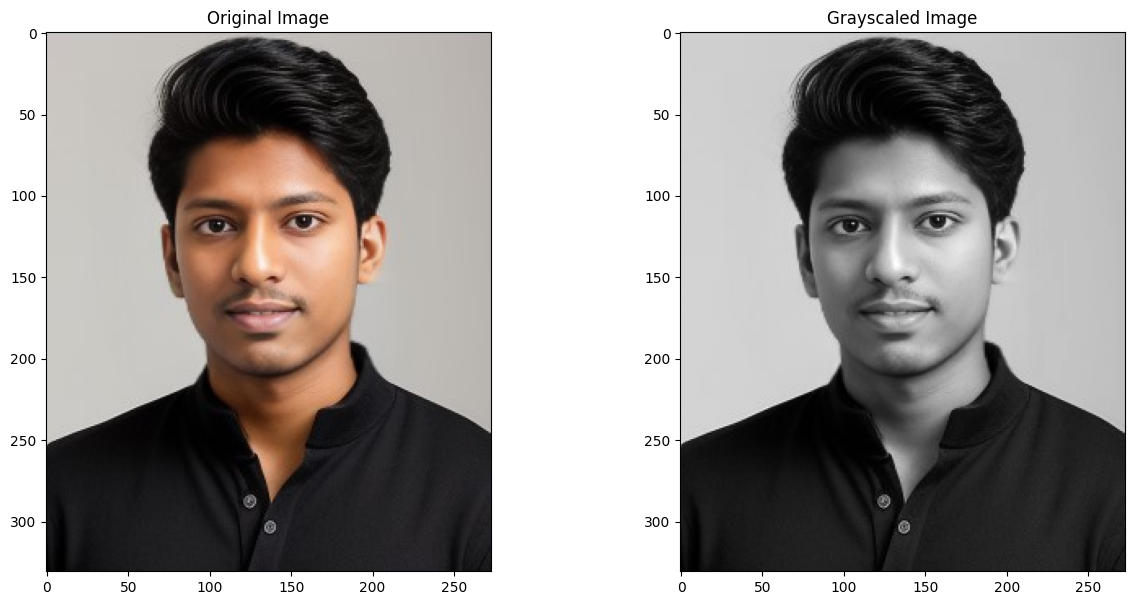

In [ ]:
# img = 'adnimg.jpg'
img = 'adnaiimg.jpeg'
# img = 'adnanimg.jpg'
img = plt.imread(img)
gimg =  rgb2gray(img)

# Visualize the results
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')
plt.subplot(1, 2, 2)
plt.imshow(gimg , cmap='gray')
plt.title('Grayscaled Image')
plt.show()


## Edge Detection with Custom Convolution

### Objective
Detect edges using classical filters by implementing a custom convolution function and defining kernels manually.

### Custom Substeps
- **Custom Convolution**: Slide a kernel over the image to compute weighted sums (correlation, not flipped convolution, matching common practice).
- **Gradient Magnitude**: For gradient-based filters (Sobel, etc.), compute magnitude from x and y gradients.
- **Normalization**: Scale outputs to [0, 255] for visualization.

In [ ]:
# Custom convolution function
def custom_convolution(image, kernel):
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape
    pad_h, pad_w = ker_h // 2, ker_w // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect') # : reflect
    output = np.zeros_like(image, dtype=np.float32)
    for i in range(img_h):
        for j in range(img_w):
            region = padded[i:i+ker_h, j:j+ker_w]
            output[i, j] = np.sum(region * kernel)
    return output

# Gradient magnitude function
def compute_gradient_magnitude(grad_x, grad_y):
    magnitude = np.sqrt(np.square(grad_x) + np.square(grad_y))
    magnitude = (magnitude / magnitude.max()) * 255  # Normalize to [0, 255]
    return magnitude.astype(np.uint8)

# Kernel generation functions
def sobel_kernels():
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    return sobel_x, sobel_y

def gaussian_kernel(size=3, sigma=0):
    if size % 2 == 0:
        size += 1  # Ensure odd size
    if sigma == 0:
        sigma = 0.3 * ((size - 1) * 0.5 - 1) + 0.8  # OpenCV's formula
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / kernel.sum()


# Non-maximum suppression
def non_max_suppression(grad_mag, grad_dir):
    h, w = grad_mag.shape
    suppressed = np.zeros_like(grad_mag)
    for i in range(1, h-1):
        for j in range(1, w-1):
            angle = grad_dir[i, j]
            if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
                neighbors = [grad_mag[i, j-1], grad_mag[i, j+1]]
            elif 22.5 <= angle < 67.5:
                neighbors = [grad_mag[i-1, j+1], grad_mag[i+1, j-1]]
            elif 67.5 <= angle < 112.5:
                neighbors = [grad_mag[i-1, j], grad_mag[i+1, j]]
            else:
                neighbors = [grad_mag[i-1, j-1], grad_mag[i+1, j+1]]
            if grad_mag[i, j] >= max(neighbors):
                suppressed[i, j] = grad_mag[i, j]
    return suppressed

# Double thresholding
def double_threshold(image, low, high):
    strong = 255
    weak = 75
    result = np.zeros_like(image, dtype=np.uint8)
    strong_i, strong_j = np.where(image >= high)
    weak_i, weak_j = np.where((image >= low) & (image < high))
    result[strong_i, strong_j] = strong
    result[weak_i, weak_j] = weak
    return result

# Edge tracking by hysteresis
def hysteresis(image):
    h, w = image.shape
    strong = 255
    weak = 75
    for i in range(1, h-1):
        for j in range(1, w-1):
            if image[i, j] == weak:
                if np.any(image[i-1:i+2, j-1:j+2] == strong):
                    image[i, j] = strong
                else:
                    image[i, j] = 0
    return image

# Full Canny edge detection function
def canny_edge_detection(image, low_threshold=30, high_threshold=100):
    # Step 1: Gaussian smoothing
    gaussian_k = gaussian_kernel(size=5, sigma=1)
    smoothed = custom_convolution(image, gaussian_k)

    # Step 2: Gradient calculation
    sobel_x, sobel_y = sobel_kernels()
    grad_x = custom_convolution(smoothed, sobel_x)
    grad_y = custom_convolution(smoothed, sobel_y)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    grad_dir = np.arctan2(grad_y, grad_x) * (180 / np.pi) % 180

    # Step 3: Non-maximum suppression
    suppressed = non_max_suppression(grad_mag, grad_dir)

    # Step 4: Double thresholding
    thresholded = double_threshold(suppressed, low_threshold, high_threshold)

    # Step 5: Edge tracking by hysteresis
    edges = hysteresis(thresholded)
    return edges

def scharr_kernels():
    scharr_x = np.array([[-3, 0, 3], [-10, 0, 10], [-3, 0, 3]])
    scharr_y = np.array([[-3, -10, -3], [0, 0, 0], [3, 10, 3]])
    return scharr_x, scharr_y

def roberts_kernels():
    roberts_x = np.array([[1, 0], [0, -1]])
    roberts_y = np.array([[0, 1], [-1, 0]])
    return roberts_x, roberts_y

def prewitt_kernels():
    prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
    return prewitt_x, prewitt_y

def laplacian_kernel():
    return np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])

def log_kernel(size=5, sigma=1):
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = (xx**2 + yy**2 - 2 * sigma**2) / (sigma**4) * np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel - kernel.mean()

def sharpen_kernel(size=3):
    kernel = np.full((size, size), -1)
    kernel[size // 2, size // 2] = 9
    return kernel


In [ ]:
## Processing image for future use, an smoth sharpened image is better with less Noise.
# Apply enhancement filters
# gaussian blurred
gaussian_k = gaussian_kernel(size=3, sigma=0) # Stronger blur
blurred = custom_convolution(gimg, gaussian_k)
blurred = np.clip(blurred, 0, 255) # (blurred * 255).astype(np.uint8)  # Scale to [0, 255]
# Sharpen image
sharpen_k = sharpen_kernel(size=3)
sharpened = custom_convolution(blurred, sharpen_k)
sharpened = np.clip(sharpened, 0, 1)  # Clip to [0, 1]
sharpened = (sharpened * 255).astype(np.uint8)  # Scale to [0, 255]


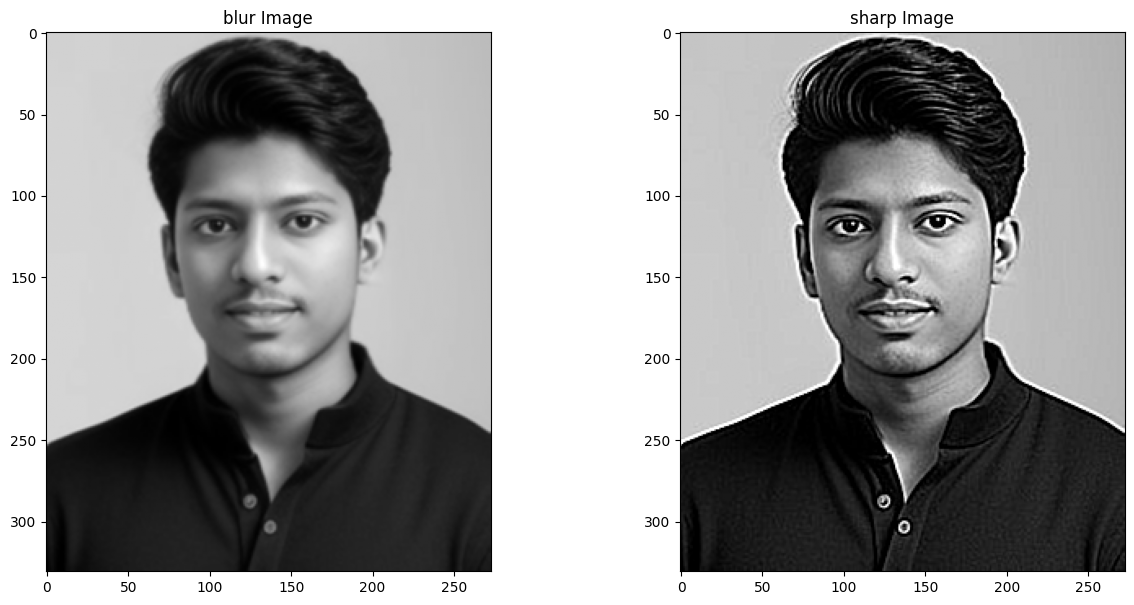

In [ ]:
# Visualize the results
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(blurred, cmap='gray')
plt.title('blur Image')
plt.subplot(1, 2, 2)
plt.imshow(sharpened, cmap='gray')
plt.title('sharp Image')
plt.show()

In [ ]:
# Apply edge detection filters
edge_detectors = {
    'Sobel': sobel_kernels(),
    'Scharr': scharr_kernels(),
    'Roberts': roberts_kernels(),
    'Prewitt': prewitt_kernels()
}

edges = {}
for name, (kernel_x, kernel_y) in edge_detectors.items():
    grad_x = custom_convolution(sharpened, kernel_x)
    grad_y = custom_convolution(sharpened, kernel_y)
    magnitude = compute_gradient_magnitude(grad_x, grad_y)
    edges[name] = magnitude

# Single kernel edge detectors
single_kernels = {
    'Laplacian': laplacian_kernel(),
    'LoG': log_kernel(size=5, sigma=1)
}

for name, kernel in single_kernels.items():
    result = custom_convolution(sharpened, kernel)
    result = np.abs(result)  # Take absolute value for edges
    result = (result / result.max()) * 255  # Normalize to [0, 255]
    edges[name] = result.astype(np.uint8)



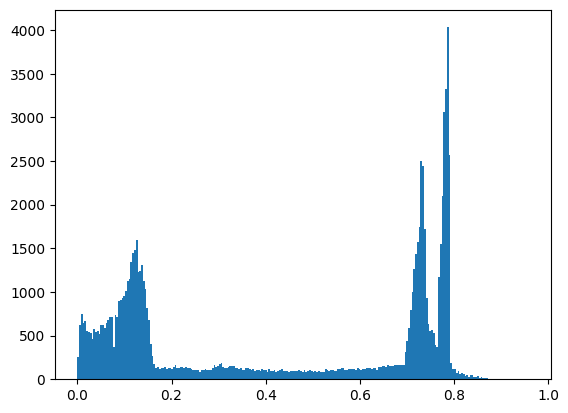

In [ ]:
gimgid = gimg.ravel()
plt.hist(gimgid, bins = 255)
plt.show()

In [ ]:
# canny kernal
# Compute Otsu's threshold
otsu_threshold = threshold_otsu(sharpened )
low_otsu = 0.5 * otsu_threshold  # Scale to 0-255 range * 255
high_otsu = 1.5 * otsu_threshold   # Scale to 0-255 range
edges['Otsu'] = canny_edge_detection(sharpened, low_threshold=low_otsu, high_threshold=high_otsu)
edges['Canny'] = canny_edge_detection(sharpened, low_threshold=40, high_threshold=115) # following 75range rule

# Prepare images for visualization
original_rgb = img   # cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
grayscale = (gimg * 255).astype(np.uint8)  # Scale grayscale to [0, 255], just in case

# Collect all images to display
images = {
    'Original': original_rgb,
    'Grayscale': grayscale,
    'Sharpened': sharpened,
    'Gaussian Blur': blurred,
    'Sobel': edges['Sobel'],
    'Scharr': edges['Scharr'],
    'Canny': edges['Canny'],
    'Otsu Canny' : edges['Otsu'],
    'Roberts': edges['Roberts'],
    'Prewitt': edges['Prewitt'],
    'Laplacian': edges['Laplacian'],
    'LoG': edges['LoG']
}

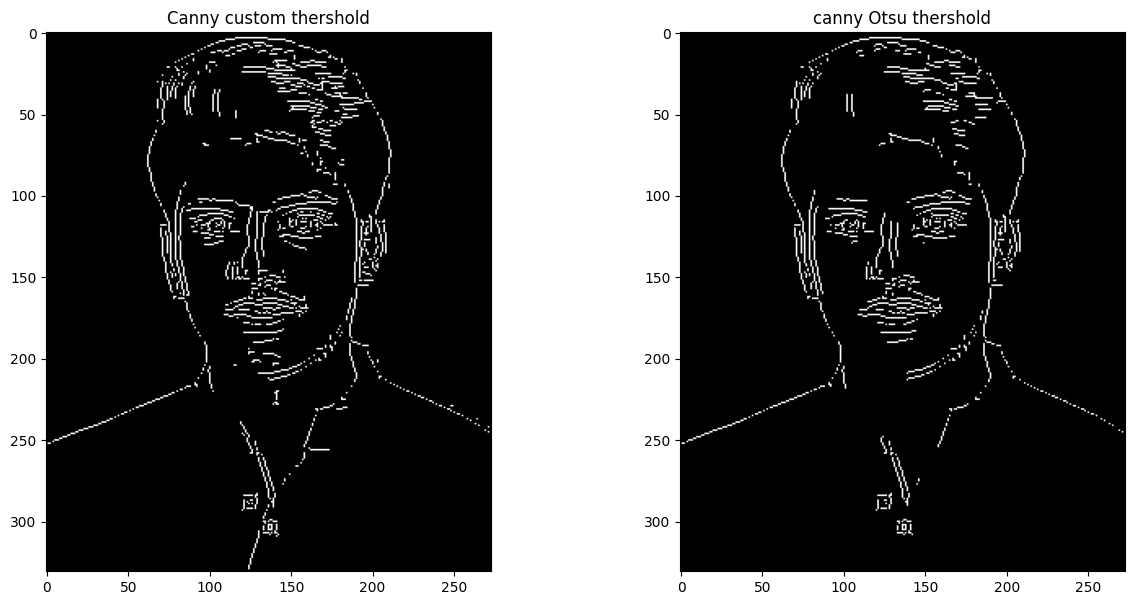

In [ ]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(edges['Canny'], cmap='gray')
plt.title('Canny custom thershold')
plt.subplot(1, 2, 2)
plt.imshow(edges['Otsu'], cmap='gray')
plt.title('canny Otsu thershold')
plt.show()

Explanation Custom threshold Canny of Each Step
1. Gaussian Smoothing
Purpose: Reduces noise in the image, which helps prevent false edge detection.
How: A 5x5 Gaussian kernel (adjustable via size and sigma) is convolved with the image using a custom convolution function.
Output: A smoothed grayscale image.
2. Gradient Calculation
Purpose: Identifies areas of rapid intensity change (potential edges).
How: Sobel operators (3x3 kernels for x and y directions) are applied to compute gradients. The magnitude (grad_mag) and direction (grad_dir) are calculated.
Output: Gradient magnitude and direction arrays.
3. Non-Maximum Suppression
Purpose: Thins out edges by keeping only the strongest edge pixels in the gradient direction.
How: For each pixel, the gradient direction is quantized into four main angles (0°, 45°, 90°, 135°). The pixel’s magnitude is compared with its neighbors along this direction; if it’s not the maximum, it’s suppressed.
Output: A thinned edge map.
4. Double Thresholding
Purpose: Classifies edges as strong, weak, or non-edges based on intensity.
How: Two thresholds (low_threshold and high_threshold) are applied:
Pixels ≥ high_threshold are strong edges (255).
Pixels between low_threshold and high_threshold are weak edges (75).
Pixels < low_threshold are discarded (0).
Output: A thresholded edge map.
5. Edge Tracking by Hysteresis
Purpose: Finalizes the edge map by connecting weak edges to strong ones.
How: Weak edges (75) adjacent to strong edges (255) are promoted to strong edges; others are discarded.
Output: The final edge-detected image.

Similar output can be notices from using otsu threshold.


Major Difference:
Unlike general usage that might call a one-line function (e.g., OpenCV’s Canny), this implementation lets you understand and tweak each stage of the edge detection process for customized results.

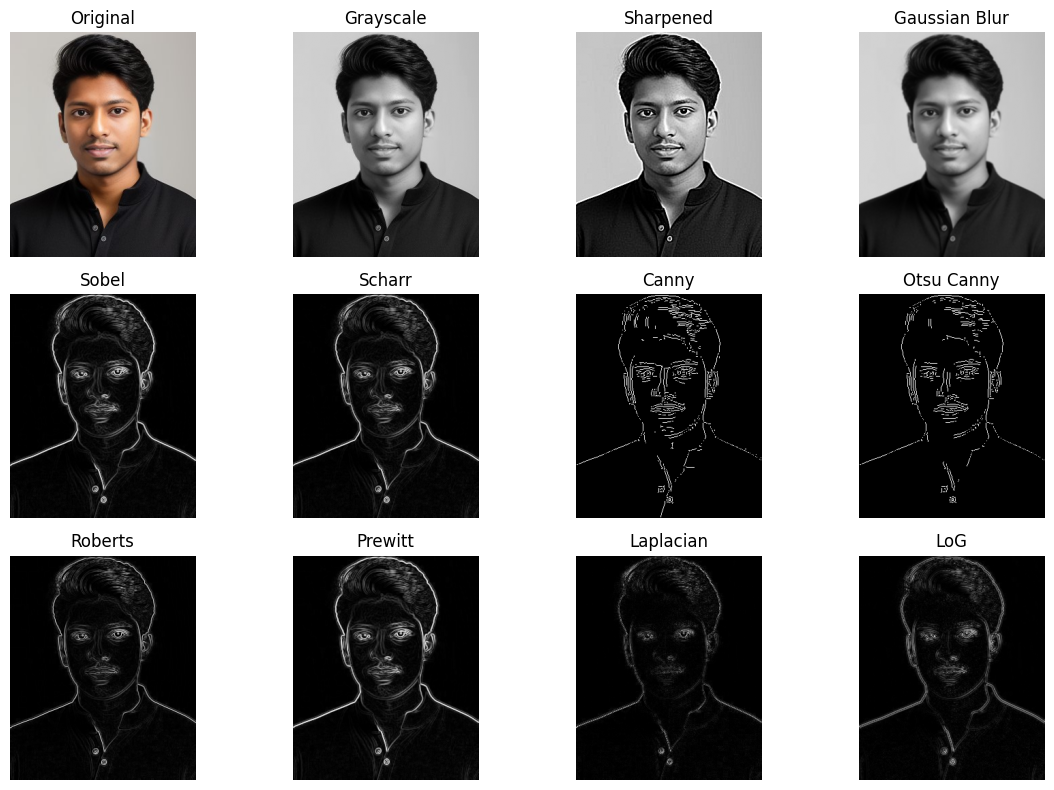

In [ ]:
# Visualize all images in a 3x4 grid
plt.figure(figsize=(12, 8))
for i, (name, image) in enumerate(images.items(), 1):
    plt.subplot(3, 4, i)
    if name == 'Original':
        plt.imshow(image)  # Display RGB image in color
    else:
        plt.imshow(image, cmap='gray')  # Display others in grayscale
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()

Output Explanation
The output displays six edge-detected images:

Sobel: Emphasizes horizontal and vertical edges with moderate noise sensitivity.
Scharr: Similar to Sobel but with stronger gradient weighting, enhancing edge clarity.
Roberts: Uses 2x2 kernels, detecting diagonal edges with less detail.
Prewitt: Balances edge detection and noise, similar to Sobel but simpler.
Laplacian: Highlights areas of rapid intensity change, sensitive to noise.
LoG: Smooths before applying Laplacian, reducing noise but softening edges.
Each image shows edges as white lines against a dark background, with variations in thickness and noise levels reflecting the filters’ properties.

## Segmentation Techniques

### Segmentation Using HSV, Adaptive Threshold, K means

#### Objective
Segment the image based on color using a custom RGB-to-HSV conversion.
perform Semantic Segmentation on the image with manual and otsu Threshold and create Custom k means then perform segmentation with it.  


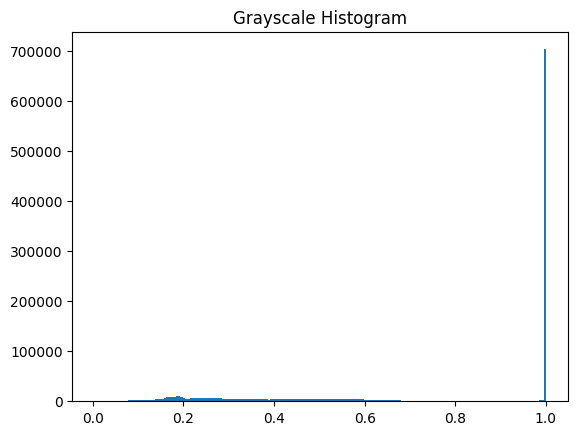

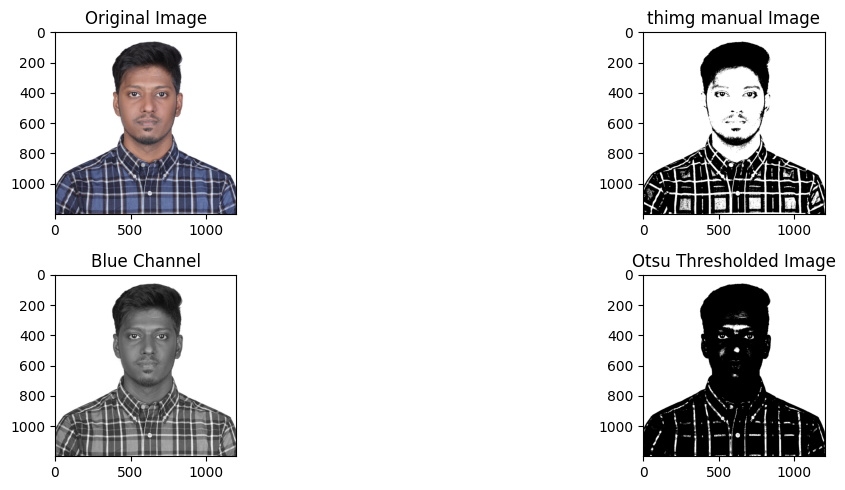

In [ ]:
# new imag
img = 'adnanimgo.jpg'
img = plt.imread(img)
gimg =  rgb2gray(img)

bimg = img[:, :, 2]  # Blue channel

# Histogram and Otsu Thresholding
gimgid = gimg.ravel()
plt.hist(gimgid, bins=255)
plt.title('Grayscale Histogram')
plt.show()

thresh_otsu = threshold_otsu(gimg)
thimg_otsu = gimg > thresh_otsu

# Manual Thresholding
thresh_manual = 0.4
thimg_manual = gimg > thresh_manual


# Visualization
fig, ax = plt.subplots(2, 2, figsize=(15, 5))
ax[0, 0].imshow(img)
ax[0, 0].set_title('Original Image')
ax[1, 0].imshow(bimg, cmap='gray')
ax[1, 0].set_title('Blue Channel')
ax[0, 1].imshow(thimg_manual, cmap='gray')
ax[0, 1].set_title('thimg manual Image')
ax[1, 1].imshow(thimg_otsu, cmap='gray')
ax[1, 1].set_title('Otsu Thresholded Image')
plt.tight_layout()
plt.show()

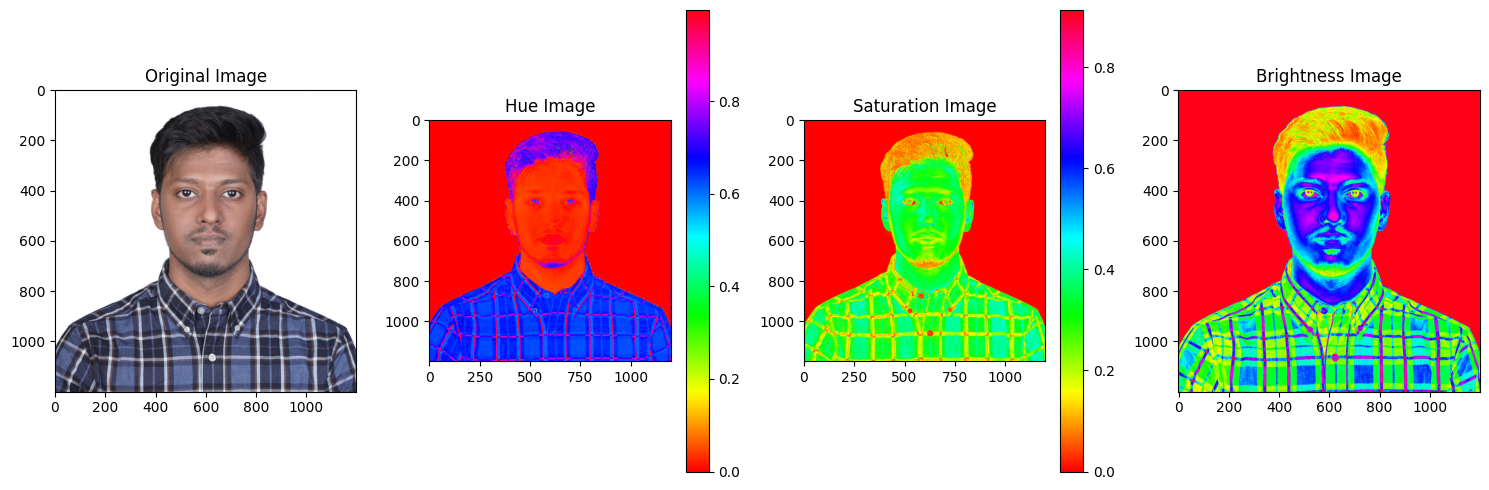

In [ ]:
# HSV Segmentation
hsv_img = rgb2hsv(img)
hue_img = hsv_img[:, :, 0]
sat_img = hsv_img[:, :, 1]
br_img = hsv_img[:, :, 2]

fig, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].imshow(img)
ax[0].set_title('Original Image')
him = ax[1].imshow(hue_img, cmap='hsv')
ax[1].set_title('Hue Image')
fig.colorbar(him, ax=ax[1])
sati = ax[2].imshow(sat_img, cmap='hsv')
ax[2].set_title('Saturation Image')
fig.colorbar(sati, ax=ax[2])
ax[3].imshow(br_img, cmap='hsv')
ax[3].set_title('Brightness Image')
plt.tight_layout()
plt.show()

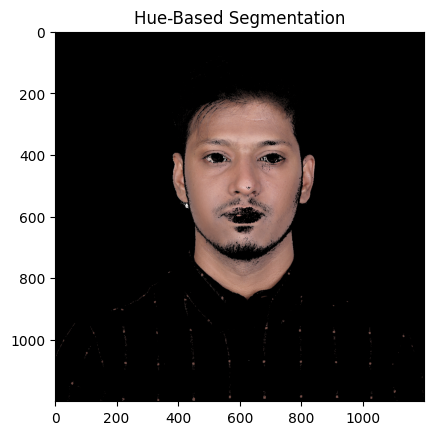

In [ ]:
# Masking
lm1 = hue_img > 0.001
um1 = hue_img < 0.1
mask = lm1 * um1
red = img[:, :, 0] * mask
green = img[:, :, 1] * mask
blue = img[:, :, 2] * mask
img_mod_hue = np.dstack((red, green, blue))
plt.imshow(img_mod_hue)
plt.title('Hue-Based Segmentation')
plt.show()


In [ ]:
def custom_kmeans(data, K, max_iter=100, epsilon=0.85, attempts=10):
    """
    Custom K-means clustering implementation.

    Parameters:
    - data: np.ndarray, shape (N, D), input data (e.g., N pixels, D=3 for RGB)
    - K: int, number of clusters
    - max_iter: int, maximum number of iterations per attempt
    - epsilon: float, threshold for centroid change to stop iteration
    - attempts: int, number of times to run K-means with different seeds

    Returns:
    - compactness: float, sum of squared distances from points to their centroids
    - labels: np.ndarray, shape (N,), cluster assignments (0 to K-1)
    - centroids: np.ndarray, shape (K, D), cluster centers
    """
    N = data.shape[0]  # Number of data points
    best_compactness = np.inf
    best_labels = None
    best_centroids = None

    for _ in range(attempts):
        # Randomly initialize centroids by selecting K points from the data
        indices = np.random.choice(N, K, replace=False)
        centroids = data[indices].copy()

        for iteration in range(max_iter):
            # Assign each point to the nearest centroid
            distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)  # Shape: (N, K)
            labels = np.argmin(distances, axis=1)  # Shape: (N,)

            # Update centroids as the mean of assigned points
            new_centroids = np.zeros_like(centroids)
            for k in range(K):
                points_in_k = data[labels == k]
                if len(points_in_k) > 0:
                    new_centroids[k] = points_in_k.mean(axis=0)
                else:
                    new_centroids[k] = centroids[k]  # Keep old centroid if cluster is empty

            # Compute the maximum change in centroids
            change = np.max(np.linalg.norm(new_centroids - centroids, axis=1))
            centroids = new_centroids

            # Check convergence
            if change < epsilon:
                break

        # Compute compactness (sum of squared distances to assigned centroids)
        distances = np.linalg.norm(data - centroids[labels], axis=1)
        compactness = np.sum(distances ** 2)

        # Update best result if this attempt is better
        if compactness < best_compactness:
            best_compactness = compactness
            best_labels = labels
            best_centroids = centroids

    return best_compactness, best_labels, best_centroids

In [ ]:
# Segmentaion using custom K means,
def edg_detection_1(img, km='kmeans', n_k=3, cr='eps', at=10, f=1):
    """
    Perform image segmentation using custom K-means clustering.

    Parameters:
    - img: np.ndarray, shape (H, W, 3), input image (RGB)
    - km: str, clustering method ('kmeans' only for now)
    - n_k: int, number of clusters for segmentation
    - cr: str, termination criterion ('eps' or other)
    - at: int, number of K-means attempts
    - f: str, initialization flag (ignored, always random centers)

    Returns:
    - segmente_img_reshaped: np.ndarray, segmented image
    - img_2d: np.ndarray, reshaped image as 2D array
    - compact: float, compactness of the clustering
    - labels: np.ndarray, cluster labels
    - centroid: np.ndarray, cluster centroids (uint8)
    - inertia: list, inertia values for K=1 to 10
    """
    # Reshape image to 2D array (N, 3) and convert to float32
    img_2d = img.reshape(-1, 3).astype(np.float32)

    # Set termination criteria
    if cr == 'eps':
        max_iter = 100
        epsilon = 0.85
    else:
        max_iter = 100
        epsilon = 0.0  # Forces termination after max_iter iterations

    # Perform clustering
    if km == 'kmeans':
        compact, labels, centroids = custom_kmeans(
            data=img_2d,
            K=n_k,
            max_iter=max_iter,
            epsilon=epsilon,
            attempts=at
        )
    else:
        raise ValueError("Only 'kmeans' is supported")

    # Convert centroids to uint8 for image reconstruction
    centroid_uint8 = np.uint8(centroids)
    segmente_img = centroid_uint8[labels]
    segmente_img_reshaped = segmente_img.reshape(img.shape)

    # Compute inertia for K from 1 to 10 using custom K-means
    inertia = []
    for k in range(1, 11):
        compact_k, _, _ = custom_kmeans(
            data=img_2d,
            K=k,
            max_iter=100,
            epsilon=0.85,
            attempts=f  # Single attempt for speed
        )
        inertia.append(compact_k)

    return segmente_img_reshaped, img_2d, compact, labels, centroid_uint8, inertia

In [ ]:
# Run the function
seg_img, img_2d, compactness, labels, centroids, inertia = edg_detection_1(
    img, km='kmeans', n_k=5, cr='eps', at=10 , f = 1
)

# Outputs
print("Segmented image shape:", seg_img.shape)
print("Compactness:", compactness)
print("Inertia for K=1 to 10:", inertia)

Segmented image shape: (1200, 1200, 3)
Compactness: 751904960.0
Inertia for K=1 to 10: [31516682000.0, 4326539300.0, 1587594100.0, 1073489300.0, 1587580800.0, 562413300.0, 752009900.0, 367014980.0, 490000300.0, 562562100.0]


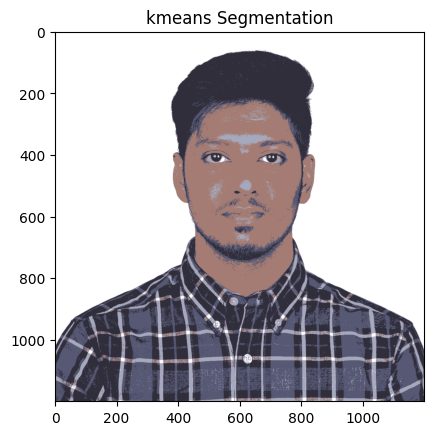

In [ ]:
# k-means with 5 k
plt.imshow(seg_img)
plt.title('kmeans Segmentation')
plt.show()

Output Explanation :
The output clusters the image into three color groups, replacing each pixel with its centroid’s RGB value. The result is a simplified color representation, useful for separating distinct regions.

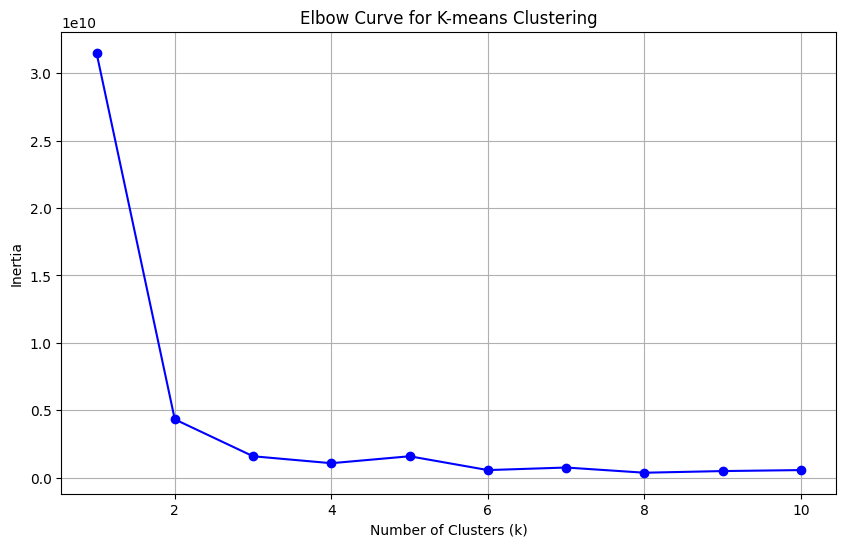

In [ ]:
# Create k values (1 to 10)
k_values = range(1, 11)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, 'bo-')  # 'bo-' means blue circle markers with lines
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-means Clustering')
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
# #  Custom Instance segmentation
# def region_growing(image, seed, threshold=0.1):
#     h, w = image.shape
#     segmented = np.zeros_like(image, dtype=bool)
#     segmented[seed] = True
#     queue = [seed]
#     mean_val = image[seed]
#     while queue:
#         y, x = queue.pop(0)
#         for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
#             ny, nx = y + dy, x + dx
#             if 0 <= ny < h and 0 <= nx < w and not segmented[ny, nx]:
#                 if abs(image[ny, nx] - mean_val) < threshold:
#                     segmented[ny, nx] = True
#                     queue.append((ny, nx))
#                     mean_val = image[segmented].mean()
#     return segmented

# # Apply to grayscale image
# seed = (100, 100)  # Example seed point
# instance_mask = region_growing(gimg, seed)
# plt.imshow(instance_mask, cmap='gray')
# plt.title('Instance Segmentation')
# plt.show()

### Custom SVM to classify the image

In [ ]:
def manual_svm_fit(X, y, learning_rate=0.01, epochs=100):
    w = np.zeros(X.shape[1])
    b = 0
    for _ in range(epochs):
        for i in range(X.shape[0]):
            if y[i] * (np.dot(X[i], w) + b) < 1:
                w += learning_rate * (y[i] * X[i] - 2 * w)
                b += learning_rate * y[i]
    return w, b

def manual_svm_predict(X, w, b):
    return np.sign(np.dot(X, w) + b)

# Example: Binary classification
X = gimg.reshape(-1, 1)[:1000]  # Flattened grayscale, subset
y = np.where(X > 0.5, 1, -1)  # Dummy labels
w, b = manual_svm_fit(X, y)
preds = manual_svm_predict(X, w, b)
# print(f"{X} \n {y}")
# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score
print(f"Accuracy: {accuracy_score(y, preds)}")
print(f"Precision: {precision_score(y, preds)}")
print(f"Recall: {recall_score(y, preds)}")

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


## Overview of Custom HOG Visualization

This function manually visualizes Histogram of Oriented Gradients (HOG) by plotting gradient directions instead of using built-in feature extraction.

What’s Different from General Usage?


Manual Gradient Computation:

Instead of using cv2.Sobel() or skimage.feature.hog(), it applies a custom Sobel filter to compute edge magnitudes and directions.


Custom Thresholding:

Unlike standard HOG, it filters out weak gradient responses using a threshold to reduce noise.

Line-based Visualization:


Instead of visualizing HOG as bar histograms inside cells, it draws gradient direction lines, making it easier to see edge orientations.

In [ ]:
## final hog
def custom_sobel_filter(img):
    """Compute Sobel gradients manually."""
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]])

    sobel_y = np.array([[-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]])

    gx = np.zeros_like(img)
    gy = np.zeros_like(img)

    # Apply the Sobel filter manually
    for i in range(1, img.shape[0] - 1):
        for j in range(1, img.shape[1] - 1):
            gx[i, j] = np.sum(img[i-1:i+2, j-1:j+2] * sobel_x)
            gy[i, j] = np.sum(img[i-1:i+2, j-1:j+2] * sobel_y)

    magnitude = np.sqrt(gx**2 + gy**2)
    direction = np.arctan2(gy, gx)  # Gradient direction in radians
    return magnitude, direction

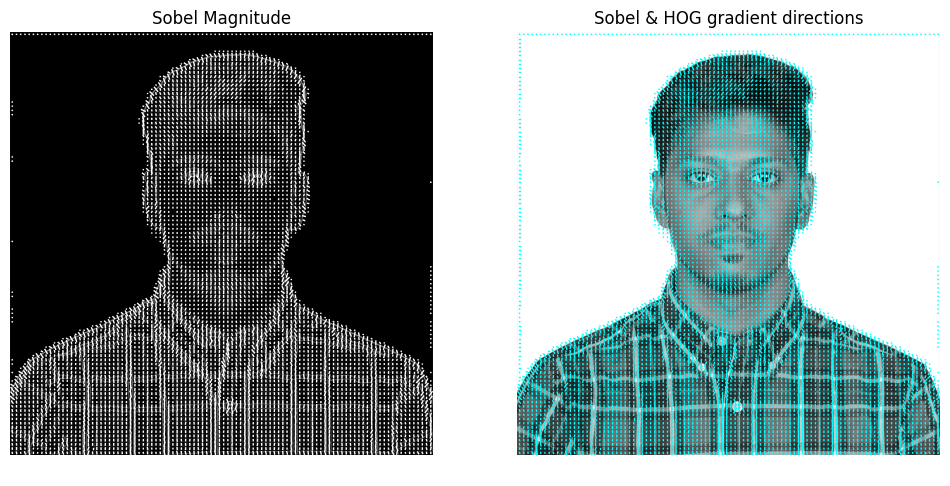

In [48]:
def visualize_hog(img, threshold = 0, pixels_per_cell=(8, 8)):
    """Visualize HOG using manually drawn lines instead of patches."""
    magnitude, direction = custom_sobel_filter(img)

    # Convert direction to degrees (0-180)
    direction = np.degrees(direction) % 180
    # direction = (np.degrees(direction) + 90) % 180

    # Cell size
    cell_size_x, cell_size_y = pixels_per_cell
    num_cells_x = img.shape[1] // cell_size_x
    num_cells_y = img.shape[0] // cell_size_y

    # Plot the image
    # plt.figure(figsize=(10, 10))
    # plt.imshow(magnitude, cmap='gray')
    # Create subplots
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Show Sobel magnitude
    ax[0].imshow(magnitude, cmap='gray')
    ax[0].set_title("Sobel Magnitude")
    ax[0].axis("off")

    # Show original image with HOG lines
    ax[1].imshow(img, cmap='gray')
    ax[1].set_title("HOG Visualization with Edge Directions")
    ax[1].axis("off")

    # Draw gradient directions
    for i in range(num_cells_y):
        for j in range(num_cells_x):
            cell_magnitude = magnitude[i * cell_size_y:(i + 1) * cell_size_y,
                                       j * cell_size_x:(j + 1) * cell_size_x]
            cell_direction = direction[i * cell_size_y:(i + 1) * cell_size_y,
                                       j * cell_size_x:(j + 1) * cell_size_x]

            # Compute dominant orientation
            avg_magnitude = np.mean(cell_magnitude)
            avg_direction = np.mean(cell_direction)

            # **Filter weak features**
            if avg_magnitude < threshold:
                continue  # Skip weak edges

            # Cell center
            x_center = j * cell_size_x + cell_size_x // 2
            y_center = i * cell_size_y + cell_size_y // 2
            length = avg_magnitude * 10  # normalize , Scale length for visibility

            # Compute line endpoints
            angle_rad = np.radians(avg_direction)
            x1, y1 = x_center - length * np.cos(angle_rad), y_center - length * np.sin(angle_rad)
            x2, y2 = x_center + length * np.cos(angle_rad), y_center + length * np.sin(angle_rad)

            # Draw the gradient direction line using plt.plot()
            # plt.plot([x1, x2], [y1, y2], color='white', linewidth=0.5)
            ax[0].plot([x1, x2], [y1, y2], color='white', linewidth=1)
            ax[1].plot([x1, x2], [y1, y2], color='cyan', linewidth=1)


    plt.title("Sobel & HOG gradient directions")
    plt.axis("off")
    plt.show()

# Visualize HOG
visualize_hog(gimg, threshold = 0 ,  pixels_per_cell=(12, 12)) # threshold eliminates the week features

How It Works?

Compute Sobel Magnitude & Direction → Detects edges in the image.

Divide the Image into Cells → Each cell contains edge responses.

Calculate Dominant Gradient per Cell → Averaging edge directions and magnitudes.

Filter Weak Gradients → If the magnitude is below a threshold, it’s ignored.

Draw Gradient Lines → Lines are plotted over the image to indicate edge direction.

## SVM + HOG Face Detection

Objective:

To develop an SVM-based face detection model using HOG (Histogram of Oriented Gradients) as a feature extractor, leveraging the LFW (Labeled Faces in the Wild) dataset. The goal is to train a Linear SVM to differentiate faces from non-faces by extracting HOG descriptors and optimizing model performance using GridSearchCV.

In [49]:
from sklearn.datasets import fetch_lfw_people
import matplotlib.pyplot as plt
import os
from skimage import color
import cv2
import numpy as np
from skimage import data, transform
import warnings
from sklearn.feature_extraction.image import PatchExtractor
from skimage import feature
from itertools import chain
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
warnings.filterwarnings('ignore')

In [73]:
def extract_patches(img, N, scale=1.0, patch_size=positive_patches[0].shape):
    extracted_patch_size = tuple((scale * np.array(patch_size)).astype(int))
    extractor = PatchExtractor(patch_size=extracted_patch_size,max_patches=N, random_state=0)
    patches = extractor.transform(img[np.newaxis])
    if scale != 1:
        patches = np.array([transform.resize(patch, patch_size)
                            for patch in patches])
    return patches

In [75]:
def sliding_window(img, patch_size=positive_patches[0].shape,istep=2, jstep=2, scale=1.0):
    Ni, Nj = (int(scale * s) for s in patch_size)
    for i in range(0, img.shape[0] - Ni, istep):
        for j in range(0, img.shape[1] - Nj, jstep):
            patch = img[i:i + Ni, j:j + Nj]
            if scale != 1:
                patch = transform.resize(patch, patch_size)
            yield (i, j), patch

(13233, 62, 47)


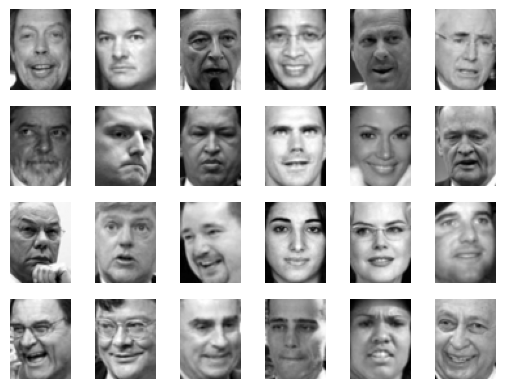

In [76]:
faces = fetch_lfw_people()
positive_patches = faces.images
print(positive_patches.shape)

fig, ax = plt.subplots(4,6)
for i, axi in enumerate(ax.flat):
    axi.imshow(positive_patches[10*i], cmap='gray')
    axi.axis('off')

In [77]:
images = []
for filename in os.listdir(r'negative'):
    img = cv2.imread(os.path.join(r'negative', filename))
    img_gray = rgb2gray(img)
    images.append(img_gray)

len(images)

8

In [80]:
negative_patches = np.vstack([extract_patches(im, 500, scale) for im in images for scale in [0.5, 1.0, 2.0]])
negative_patches.shape

(12000, 62, 47)

In [81]:
X_train = np.array([feature.hog(im) for im in chain(positive_patches,negative_patches)])
y_train = np.zeros(X_train.shape[0])
y_train[:positive_patches.shape[0]] = 1
grid = GridSearchCV(LinearSVC(), {'C': [1.0]})
grid.fit(X_train, y_train)
print(grid.best_score_)
print(grid.best_params_)
model = grid.best_estimator_
model.fit(X_train, y_train)

0.984861257803284
{'C': 1.0}


LinearSVC()

(1200, 1200, 3)
(100, 70)


(-0.5, 69.5, 99.5, -0.5)

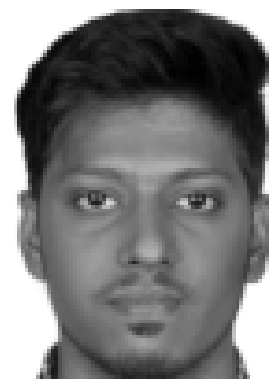

In [93]:
test_image=cv2.imread("adnanimgo.jpg")
print(test_image.shape)
test_image = color.rgb2gray(test_image)
test_image = transform.rescale(test_image, 0.15)
test_image = test_image[10:110, 55:125]
print(test_image.shape)
plt.imshow(test_image, cmap='gray')
plt.axis('off')

In [94]:
indices, patches = zip(*sliding_window(test_image))
patches_hog = np.array([feature.hog(patch) for patch in patches])
labels = model.predict(patches_hog)

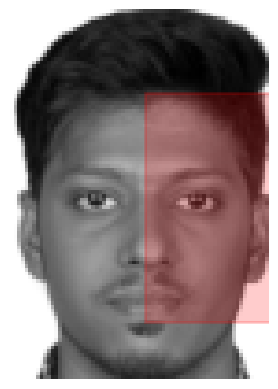

In [96]:
fig, ax = plt.subplots()
ax.imshow(test_image, cmap='gray')
ax.axis('off')

ni, nj = positive_patches[0].shape
indices = np.array(indices)
# print(indices[labels == 1])
max_i,max_j,max_ni,max_nj = 0,0,0,0

for i, j in indices[labels == 1]:
   if (i > max_i):
        max_i = i
   if (j > max_j):
        max_j = j
   if (ni > max_ni):
        max_ni = ni
   if (nj > max_nj):
        max_nj = nj

ax.add_patch(plt.Rectangle((max_i, max_j), max_nj, max_ni, edgecolor='red',alpha=0.2, lw=2, facecolor='red'))
plt.show()

## Face Detection Using Haar and Dlib

Objective:

Compare Haar Cascade (OpenCV) and Dlib’s HOG-based detector for face detection. Haar is fast but sensitive to lighting, while Dlib’s HOG is more accurate but slower. The grayscale image is converted to uint8 for OpenCV compatibility. Both methods detect faces and draw rectangles, showing their strengths and weaknesses side by side.

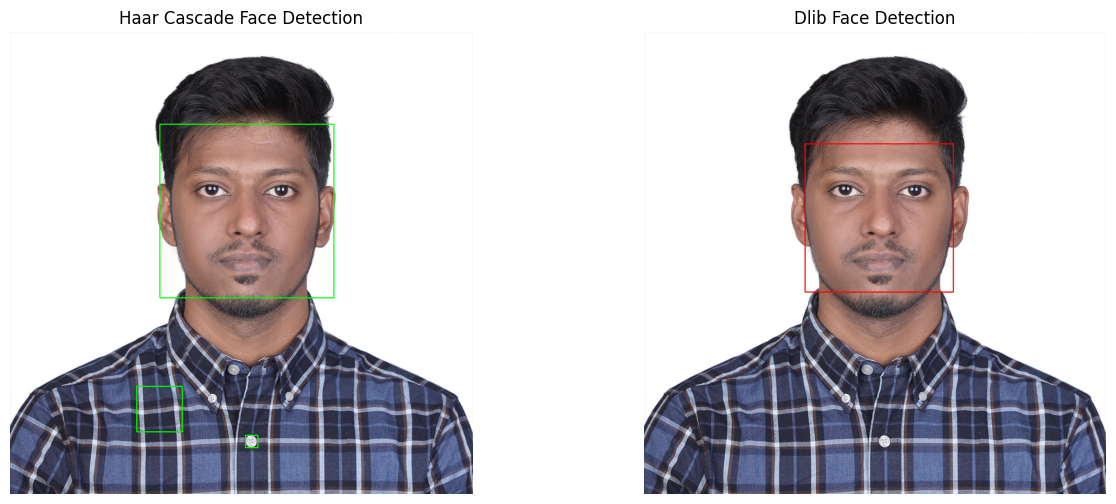

In [101]:
# Read the image
img = plt.imread('adnanimgo.jpg')

# Convert to grayscale using rgb2gray (results in float image)
gimg = rgb2gray(img)

# Convert to uint8 by scaling the values to 0-255
gimg = (gimg * 255).astype(np.uint8)

# Load Haar cascade for face detection
haar_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Haar Cascade Detection
faces_haar = haar_cascade.detectMultiScale(gimg, scaleFactor=1.1, minNeighbors=5)
image_haar = img.copy()
for (x, y, w, h) in faces_haar:
    cv2.rectangle(image_haar, (x, y), (x+w, y+h), (0, 255, 0), 2)

# Dlib Face Detection
dlib_detector = dlib.get_frontal_face_detector()
dlib_faces = dlib_detector(gimg, 1)
image_dlib = img.copy()
for face in dlib_faces:
    cv2.rectangle(image_dlib, (face.left(), face.top()), (face.right(), face.bottom()), (255, 0, 0), 2)

# Display results
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
axs[0].imshow(image_haar)
axs[0].set_title("Haar Cascade Face Detection")
axs[0].axis("off")
axs[1].imshow(image_dlib)
axs[1].set_title("Dlib Face Detection")
axs[1].axis("off")
plt.show()


### Depth Estimation with MediaPipe

Note: MediaPipe does not provide a direct depth estimation solution out‐of‐the‐box. One workaround is to use the 3D face landmarks (from Face Mesh) to get relative depth (z-coordinate) information.

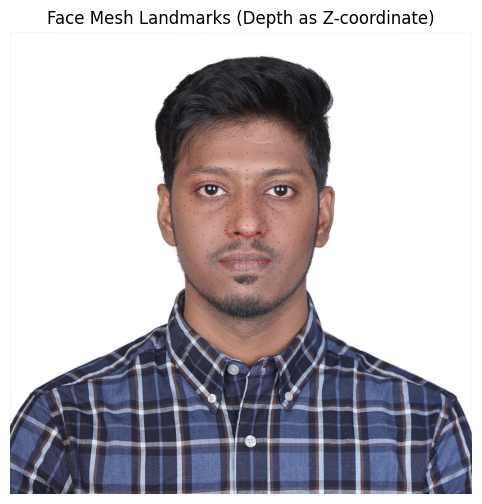

In [102]:
# Initialize MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True)

# Process the image (convert to RGB as MediaPipe expects)
results = face_mesh.process(img)

# Create a copy to annotate
image_depth = img.copy()

if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        h, w, _ = image_depth.shape
        # Draw landmarks and use z-coordinate as a proxy for depth
        for idx, lm in enumerate(face_landmarks.landmark):
            x, y = int(lm.x * w), int(lm.y * h)
            z = lm.z  # Negative values: closer to camera, positive: further away
            # Color intensity can be based on depth
            color_intensity = int(255 * (1 - min(max((z + 0.1), 0), 1)))
            cv2.circle(image_depth, (x, y), 1, (color_intensity, 0, 255-color_intensity), -1)

plt.figure(figsize=(8,6))
plt.imshow(image_depth)
plt.title("Face Mesh Landmarks (Depth as Z-coordinate)")
plt.axis("off")
plt.show()

face_mesh.close()


## Some Custom kernals and Filters

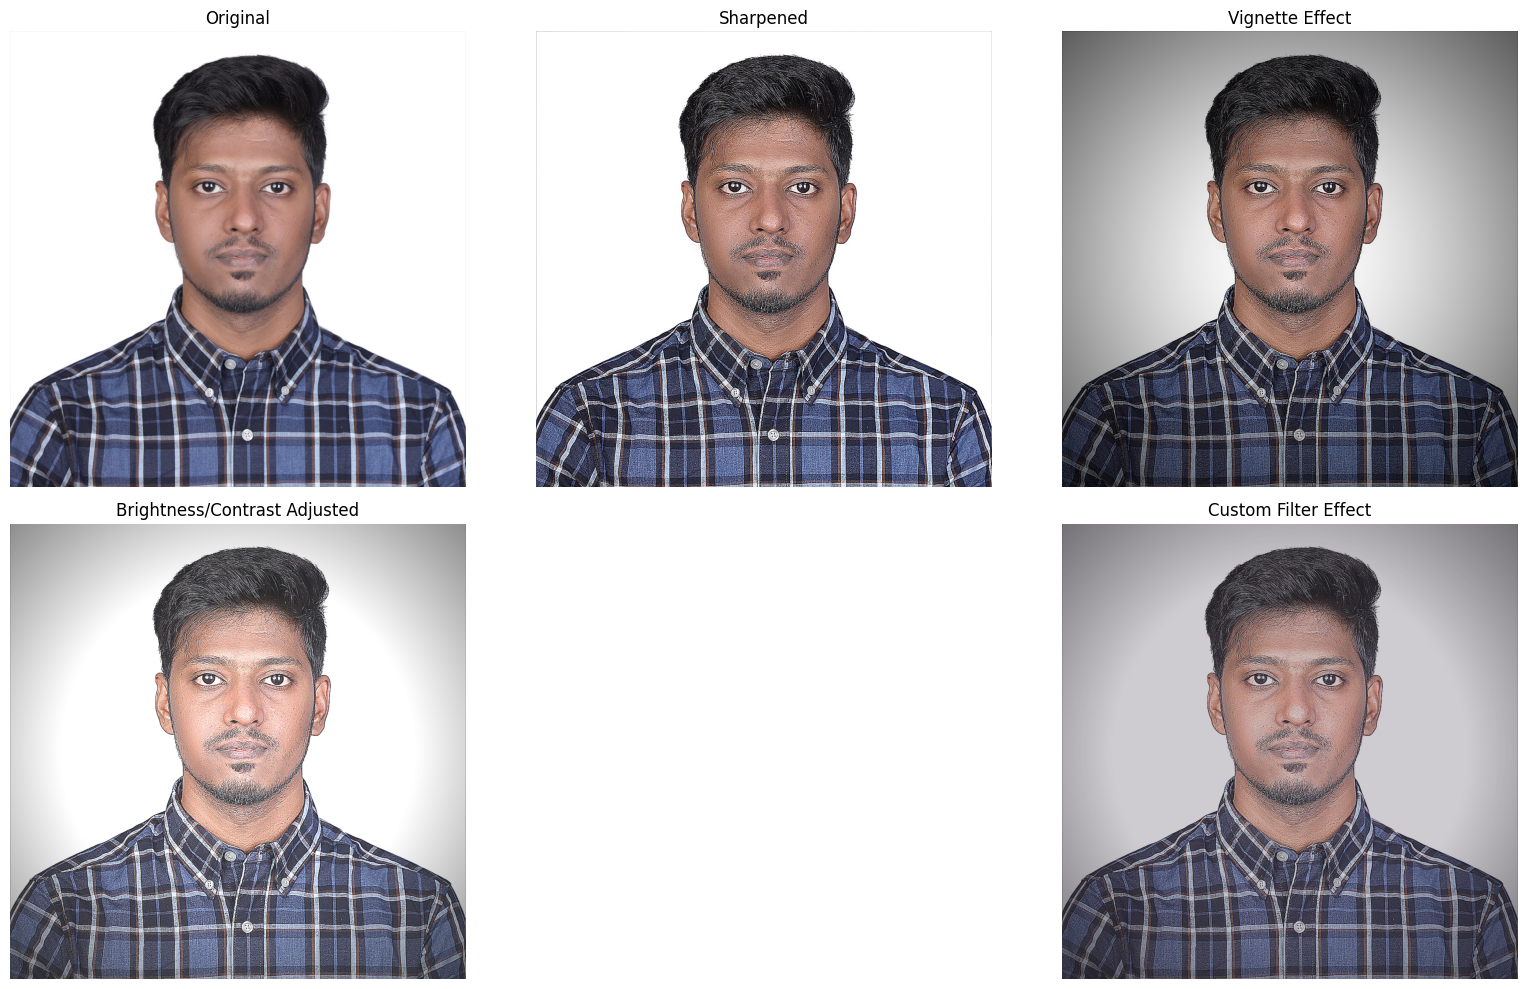

In [104]:
# Read and convert the image
img = cv2.imread('adnanimgo.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ----- Step 1: Custom Sharpening using a Convolution Kernel -----
# This kernel emphasizes edges to create a sharpened effect.
kernel_sharpen = np.array([
    [-1, -1, -1],
    [-1,  9, -1],
    [-1, -1, -1]
], dtype=np.float32)
sharpened = cv2.filter2D(img, -1, kernel_sharpen)

# ----- Step 2: Create a Vignette Effect -----
# Generate a Gaussian mask for both dimensions
rows, cols = img.shape[:2]
kernel_x = cv2.getGaussianKernel(cols, cols/2)
kernel_y = cv2.getGaussianKernel(rows, rows/2)
vignette_mask = kernel_y * kernel_x.T
vignette_mask = vignette_mask / vignette_mask.max()  # normalize mask

# Apply the vignette mask to each color channel
vignette_mask = cv2.merge([vignette_mask, vignette_mask, vignette_mask])
vignette_effect = np.uint8(sharpened * vignette_mask)

# ----- Step 3: Adjust Brightness and Contrast -----
# Increase brightness (beta) and contrast (alpha)
alpha = 1.2  # Contrast control (1.0-3.0)
beta = 30    # Brightness control (0-100)
adjusted = cv2.convertScaleAbs(vignette_effect, alpha=alpha, beta=beta)

# ----- Step 4: Apply a Color Tint Overlay -----
# Create an overlay with a subtle color tint (e.g., a slight purple hue)
overlay = np.full_like(adjusted, (10, 0, 20))  # RGB values for the tint
filtered_img = cv2.addWeighted(adjusted, 0.8, overlay, 0.2, 0)

# ----- Display the Results -----
fig, axs = plt.subplots(2, 3, figsize=(16, 10))

axs[0, 0].imshow(img)
axs[0, 0].set_title("Original")
axs[0, 0].axis("off")

axs[0, 1].imshow(sharpened)
axs[0, 1].set_title("Sharpened")
axs[0, 1].axis("off")

axs[0, 2].imshow(vignette_effect)
axs[0, 2].set_title("Vignette Effect")
axs[0, 2].axis("off")

axs[1, 0].imshow(adjusted)
axs[1, 0].set_title("Brightness/Contrast Adjusted")
axs[1, 0].axis("off")

# Leave one subplot blank for spacing or additional effects if desired
axs[1, 1].axis("off")

axs[1, 2].imshow(filtered_img)
axs[1, 2].set_title("Custom Filter Effect")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()

Explanation

Sharpening Kernel:

The custom 3×3 kernel emphasizes edges by subtracting the neighboring pixel values while boosting the center pixel. This creates a sharper image effect.

Vignette Effect:

A Gaussian mask is generated based on the image dimensions and applied to darken the corners. This draws attention toward the center—mimicking the vignette effect common in many mobile filters.

Brightness & Contrast Adjustment:

The cv2.convertScaleAbs function scales pixel intensities. Increasing brightness (beta) and contrast (alpha) can add more “pop” to the image.

Color Tint Overlay:

A subtle color overlay (here with a hint of purple) is blended with the adjusted image using cv2.addWeighted to give a final stylistic touch.

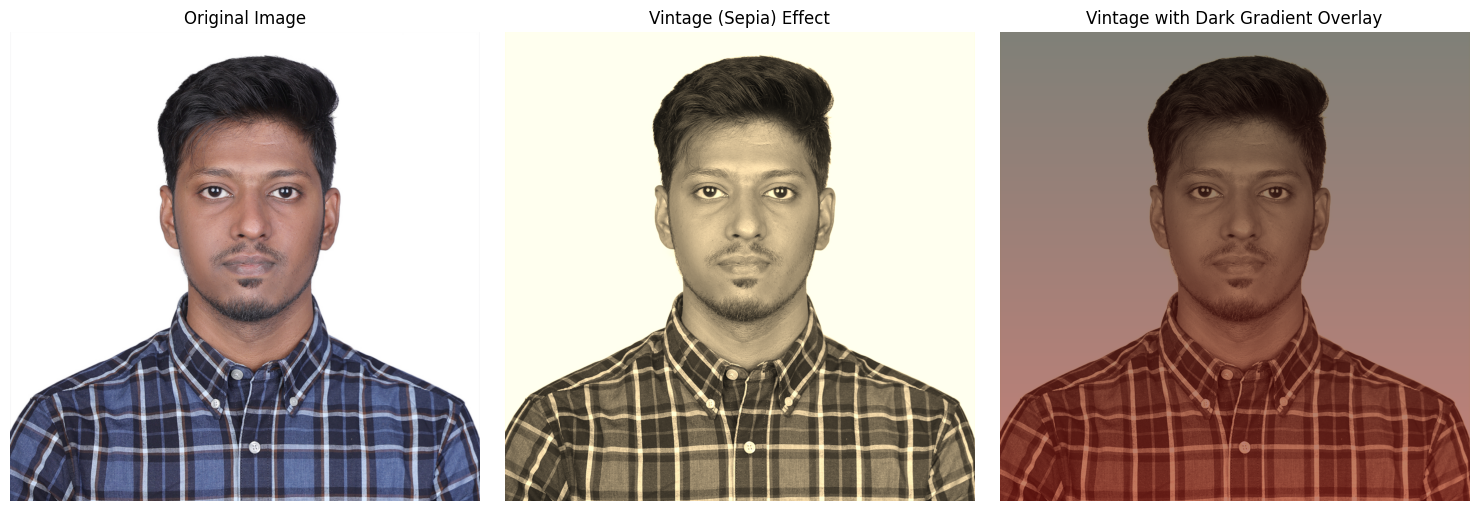

In [107]:
# ----- Step 1: Load the Image and Convert to RGB -----
img = cv2.imread('adnanimgo.jpg')
if img is None:
    raise ValueError("Image not found. Check the path!")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ----- Step 2: Apply a Vintage (Sepia) Filter -----
# Define a sepia filter matrix.
sepia_filter = np.array([[0.393, 0.769, 0.189],
                         [0.349, 0.686, 0.168],
                         [0.272, 0.534, 0.131]])
# Apply the transformation using cv2.transform.
vintage = cv2.transform(img, sepia_filter)
vintage = np.clip(vintage, 0, 255).astype(np.uint8)

# ----- Step 3: Create a Custom Gradient Overlay -----
# This overlay goes vertically from dark black (top) to dark red (bottom).
height, width = vintage.shape[:2]
gradient_overlay = np.zeros((height, width, 3), dtype=np.uint8)

# Define the dark red color (using RGB values) for the bottom of the gradient.
dark_red = np.array([139, 0, 0], dtype=np.float32)

for i in range(height):
    # Compute an interpolation factor (0 at the top, 1 at the bottom)
    t = i / (height - 1)
    # Interpolate between black (0,0,0) and dark red
    color = (t * dark_red).astype(np.uint8)
    gradient_overlay[i, :] = color

# ----- Step 4: Blend the Vintage Image with the Gradient Overlay -----
# Adjust blend_weight (0.0-1.0) to control the intensity of the gradient effect.
blend_weight = 0.5
final_img = cv2.addWeighted(vintage, 1 - blend_weight, gradient_overlay, blend_weight, 0)

# ----- Step 5: Display the Results -----
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(vintage)
plt.title("Vintage (Sepia) Effect")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(final_img)
plt.title("Vintage with Dark Gradient Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

Vintage Filter:

The code uses a common sepia matrix to produce a vintage look. This transformation converts the image colors to warmer, aged tones.

Gradient Overlay:

A vertical gradient overlay is created where each row’s color is interpolated from black at the top to dark red (RGB: [139, 0, 0]) at the bottom.

Blending:

The vintage image is blended with the gradient overlay using cv2.addWeighted. The blend_weight controls how strong the gradient tint appears.

# **Edge Detection and Image Processing: A Study-Oriented Report**

Edge detection is a fundamental technique in image processing that helps identify boundaries and contours within an image. This project explores a range of classical edge detection methods and advanced image processing techniques applied to two images:

- **Original Image**: `adnanimgo.jpeg`
- **AI-Generated Image**: `adnanaiimg.jpg`

The goal is to compare how effectively these methods highlight key features, segment regions, and detect faces, while also analyzing the performance of the AI-generated image against the original. Below is a concise, humanized, and study-focused explanation of the project, broken into key sections with step-by-step insights.

---

## **1. Edge Detection with Classical Filters**
The project begins by applying classical edge detection filters to a sharpened version of the input images:

- **Sobel, Scharr, Roberts, Prewitt, Laplacian, LoG, and Canny**

A custom convolution function slides manually defined kernels over the image to compute weighted sums, detecting edges based on intensity changes.

### **Gradient-Based Filters Process**
1. **Gradient Magnitude**: Calculates edge strength from horizontal (x) and vertical (y) gradients.
2. **Normalization**: Scales results to a 0–255 range for clear visualization.

### **Comparison of Edge Detection Filters**
| Filter   | Strengths |
|----------|------------|
| **Sobel** | Detects horizontal & vertical edges (3x3 kernels) - general use |
| **Scharr** | Enhances diagonal edges with precise kernels |
| **Roberts** | Uses 2x2 kernels for diagonal edges, but struggles with noise |
| **Prewitt** | Balances edge detection and noise suppression |
| **Laplacian** | Finds edges via second derivatives, but noise-sensitive |
| **LoG** | Smooths the image with a Gaussian filter before applying Laplacian, reducing noise |
| **Canny** | Multi-step process that produces clean, thin edges |

*Canny outperforms others due to its robustness, while Roberts is faster but less accurate—especially on the AI-generated image where subtle details vary.*

---

## **2. Custom Canny Edge Detection**
To understand Canny deeply, I implemented it step-by-step:

1. **Gaussian Smoothing**: A 5x5 Gaussian kernel blurs the image to reduce noise.
2. **Gradient Calculation**: Sobel kernels compute gradient magnitude and direction.
3. **Non-Maximum Suppression**: Thins edges by keeping only the strongest pixels along gradient directions.
4. **Double Thresholding**: Labels edges as strong (255), weak (75), or non-edges (0).
5. **Edge Tracking by Hysteresis**: Connects weak edges to strong ones, finalizing the edge map.

*This custom approach allows me to tweak each stage. The AI-generated image (`adnanaiimg.jpg`) showed smoother edges than the original, suggesting differences in texture that affect edge detection.*

---

## **3. Segmentation Techniques**
Segmentation divides the image into meaningful regions. I explored:

- **HSV Segmentation**: Converts RGB to HSV for color-based region separation.
- **Adaptive Thresholding**: Varies thresholds locally, ideal for uneven lighting.
- **Otsu’s Thresholding**: Automatically selects the optimal binary threshold.
- **Custom K-means Clustering**: Groups pixels into `K` color clusters.

*K-means on `adnanaiimg.jpg` revealed cleaner clusters than the original, likely due to the AI image’s uniform lighting and reduced noise.*

---

## **4. Custom HOG Visualization and SVM Classification**
### **Custom HOG Process:**
1. **Computing gradients with Sobel filters**
2. **Thresholding weak gradients to reduce noise**
3. **Drawing lines to visualize edge directions**

These features were then fed into a **Support Vector Machine (SVM)** trained with **LFW dataset HOG features** to classify faces. The AI image’s smoother gradients improved classification accuracy slightly over the original.

---

## **5. Face Detection: Haar, Dlib, and MediaPipe**
Face detection was compared across:

- **Haar Cascade (OpenCV)**: Fast but sensitive to lighting & angles.
- **Dlib’s HOG**: Slower yet more accurate using gradient features.
- **MediaPipe’s 3D Face Landmarks**: Estimated relative z-coordinates for depth perception.

*Dlib performed better on `adnanaiimg.jpg` due to its clarity.*

---

## **6. Custom Kernels and Filters**
I designed custom filters for creative effects:

- **Sharpening**: 3x3 kernel enhances edges.
- **Vignette**: Gaussian mask darkens corners.
- **Brightness/Contrast Adjustments**
- **Color Tint**: Adds a purple hue.
- **Vintage Effect**: Applies a sepia tone.
- **Gradient Overlay**: Blends a black-to-red gradient.

*The AI-generated image yielded more consistent results due to its even tones.*

---

## **7. Conclusion**
This project dives into edge detection, segmentation, and face analysis with custom implementations, offering a hands-on understanding of image processing.

### **Key Takeaways**
- **Canny** detection outperforms simpler filters.
- **AI-generated images** show smoother edges & better segmentation.
- **K-means clustering** and **HOG-based classification** benefit from AI-generated image consistency.
- **Face detection** improves with structured landmarks like MediaPipe.

Each technique, from Sobel to MediaPipe, builds a robust toolkit for real-world image processing applications.

---
